In [1]:
# System
import sys 
sys.path.append("../")

# Data processing
import pandas as pd
import xarray as xr
import numpy as np
import math

# Plotting 
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask

# Stat and ML
from scipy import stats
from sklearn.model_selection import train_test_split
from tqdm import tqdm 
from statsmodels.tsa.stattools import grangercausalitytests
from scipy.stats import chi2
from sklearn.ensemble import RandomForestRegressor
from scipy.signal import detrend
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.model_selection import cross_val_score, KFold

# Personal library
from models.granger_pca import GrangerPCA
from models.teleconnection_models import RegressionAnalysis, CompositeAnalysis, CanonicalCorrelationAnalysis, SpatialAveraging, PrincipalComponents
from src.granger_causality_test import test_granger_causality, test_granger_causality_non_parametric
from src.xarray_numpy import xr2np, np2D_to_np3D
from src.utils import generate_past_data, lag_analysis, plot_lag_results, compute_aic_bic, explained_variance_ratio_fast
from src.plot_weights import *

np.random.seed(1234)

### Experiments parameters

In [2]:
region = 'Europe' # Region for analysis (Europe or India)
coarsen_factor = 2 # Coarsaning factor of precipitation
detrending = True # Detrending NAO and precipitations
logtransform = True # Log transforming precipitations
train_ratio = 0.8 # Train test split ratio
ncp = 20 # number of PCA
alphas = np.logspace(-5, 20, 100) # Search space for ridge regression hyperparameter
if region=='India':
    lag = 10 # Lag for NAO -> Precip in India (between 5 and 20)
elif region=='Europe':
    lag = 3 # Lag for NAO -> Precip in India (between 1 and 20)

## Loading data

In [3]:
if region=='India':
    precip_dataset = xr.open_dataset('/home/homer/Documents/Research/Data/ERA5/pr/era5_total_pr_daily_india.nc').coarsen(latitude=coarsen_factor, longitude=coarsen_factor, boundary='trim').mean()
    ds = precip_dataset.sortby("valid_time")
    # Remove last 17 days to match oscillation/European data time span
    precip_dataset = ds.isel(valid_time=slice(None, -17))

elif region=='Europe':
    precip_dataset = xr.open_dataset('/home/homer/Documents/Research/Data/ERA5/pr/era5_total_pr_daily_europe_72N_34N_25W_45E.nc').coarsen(latitude=coarsen_factor, longitude=coarsen_factor, boundary='trim').mean()
# Removing anomalies
seasonalities = precip_dataset.groupby('valid_time.month').mean('valid_time')
precip_anomalies = precip_dataset.groupby('valid_time.month') - seasonalities



# Create land mask: land = integer, ocean = NaN
land = regionmask.defined_regions.natural_earth_v5_0_0.land_50
mask = land.mask(precip_anomalies.tp, lon_name='longitude', lat_name='latitude')

anomalies = xr2np(precip_anomalies, mask, var='tp')

valid_dates = pd.to_datetime(precip_anomalies.valid_time.values)
df = pd.read_csv( "/home/homer/Documents/Research/Data/Climate_Oscillation/norm.daily.nao.cdas.z500.19500101_current.csv")
df["date"] = pd.to_datetime(df[["year", "month", "day"]])
df.set_index("date", inplace=True)

df_selected = df.loc[df.index.intersection(valid_dates)]

oscillation = df_selected['nao_index_cdas'].fillna(0).to_numpy()

/tmp/ipykernel_6477/674524189.py:16: UserWarning: `land_50` of `natural_earth_v4_1_0` and `natural_earth_v5_0_0` does not quite extend to 90°S - it's recommended to use `natural_earth_v5_1_2` instead. See https://github.com/regionmask/regionmask/issues/487
  land = regionmask.defined_regions.natural_earth_v5_0_0.land_50
/home/homer/anaconda3/envs/gpca/lib/python3.9/site-packages/regionmask/core/mask.py:179: FutureWarning: Passing 'lon_name' and 'lat_name' was deprecated in v0.10.0. Please pass the coordinates directly, e.g., `mask*(ds[lon_name], ds[lat_name])`.
  warnings.warn(


In [4]:
# Detrending
if detrending:
    anomalies = detrend(anomalies, axis=0, type='linear')
    oscillation = detrend(oscillation, axis=0, type='linear')
# Log transform
if logtransform:
    anomalies = anomalies - np.min(anomalies) + 1e-8
    anomalies = np.log(anomalies)

## Data preprocessing

In [5]:
# Data splitting
n = len(anomalies)
train_size = int(n * train_ratio)

anomalies_train = anomalies[:train_size, :]
anomalies_test  = anomalies[train_size:, :]

oscillation_train = oscillation[:train_size]
oscillation_test  = oscillation[train_size:]

In [6]:
pca = PCA(n_components=ncp)
pca.fit(anomalies_train)

anomalies_pca_train = pca.transform(anomalies_train)
anomalies_pca_test = pca.transform(anomalies_test)

anomalies_pca = pca.transform(anomalies)

## Fitting Granger PCA
* Seting maxlag to *None* to that optimal lag is selected to maximise the *lag_criterion* score of a model predicting $Y$ from $X$ and $Y$'s pasts.
* Different algorithms are available: *diff_ratio* maximise the F-statistic, *ratio* maximise the likelihood ratio and *difference* maximise the RSS difference

In [7]:
gpca = GrangerPCA(maxlag=lag, maxlags=range(1, 5), #method='diff_ratio', lag_criterion='r2_median',  #Lag selection
                  model_res=RidgeCV(alphas=alphas), model_full=RidgeCV(alphas=alphas), alpha=1e-7, #Regression models and stabilisation
                  residuals_computation="block_cv", block_cv_n_blocks=5) # Scheme for computing residuals
                  #, mu='optimal', test_level=1e-2) #Granger PCA regularisation
gpca.fit(oscillation_train[:, None], anomalies_pca_train, plot_lag_analysis=True, verbose=True)

conflicted sign: lag 1:negative, lag 2:positive, lag 3:positive
       eigs
0  0.318346
1  0.035861
2  0.018398


In [8]:
cp_test_gpca = gpca.transform(anomalies_pca_test)

## Fitting other algorithms
* Using the same optimal time lag found during Granger PCA analysis 

In [9]:
ca = CompositeAnalysis(maxlag=gpca.maxlag)
ca.fit(oscillation_train[:, None], anomalies_pca_train)
cp_test_ca = ca.transform(anomalies_pca_test, type='PosNeg')

ra = RegressionAnalysis(maxlag=gpca.maxlag)
ra.fit(oscillation_train[:, None], anomalies_pca_train)
cp_test_ra = ra.transform(anomalies_pca_test)

cca = CanonicalCorrelationAnalysis(maxlag=gpca.maxlag, n_components=1)
cca.fit(oscillation_train[:, None], anomalies_pca_train)
cp_test_cca = cca.transform(anomalies_pca_test)

sa = SpatialAveraging()
sa.fit(oscillation_train[:, None], anomalies_train)
cp_test_sa = sa.transform(anomalies_test)

pc = PrincipalComponents()
pc.fit(oscillation_train[:, None], anomalies_train)
cp_test_pc = pc.transform(anomalies_test)

In [10]:
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import t as student_t

def get_weights(anomalies_pca, anomalies, algo, idx=0, mode="correlation"):
    """
    Parameters
    ----------
    anomalies_pca : array-like, shape (n_samples, n_features_pca)
    anomalies : array-like, shape (n_samples, n_pixels)
    algo : fitted PCA-like object with transform method
    idx : int
        Index of component to use
    mode : {"regression", "correlation"}
    
    Returns
    -------
    If mode == "regression":
        coef : array (n_pixels,)
    If mode == "correlation":
        corr : array (n_pixels,)
        sig  : boolean array (n_pixels,) True where significant at 5%
    """

    cp = algo.transform(anomalies_pca)
    if cp.ndim > 1 and cp.shape[1] > 1:
        cp = cp[:, idx]

    if mode == "regression":
        lr = LinearRegression()
        lr.fit(anomalies, cp)
        return lr.coef_

    elif mode == "correlation":
        cp = np.asarray(cp).ravel()
        n = cp.size

        # Center
        cp_c = cp - cp.mean()
        anomalies_c = anomalies - anomalies.mean(axis=0)

        # Norms
        cp_norm = np.sqrt(np.sum(cp_c**2))
        anomalies_norm = np.sqrt(np.sum(anomalies_c**2, axis=0))

        # Covariance
        cov = np.sum(anomalies_c * cp_c[:, None], axis=0)

        # Correlation
        corr = cov / (cp_norm * anomalies_norm)

        # ---- Significance test (two-sided, alpha=0.05) ----
        df = n - 2
        t_stat = corr * np.sqrt(df / (1 - corr**2))
        p_values = 2 * (1 - student_t.cdf(np.abs(t_stat), df))

        significance = p_values < 0.05

        return corr, significance

    else:
        raise ValueError(f"Unknown mode '{mode}'. Use 'regression' or 'correlation'.")


corr_ca, significance_ca = get_weights(anomalies_pca, anomalies, ca)
corr_ra, significance_ra  = get_weights(anomalies_pca, anomalies, ra)
corr_cca, significance_cca  = get_weights(anomalies_pca, anomalies, cca)
corr_pc, significance_pc  = get_weights(anomalies, anomalies, pc)
corr_sa, significance_sa  = get_weights(anomalies, anomalies, sa)
idx = 0 # Which GPC
corr_gpca, significance_gpca  = get_weights(anomalies_pca, anomalies, gpca, idx=0)

## Testing Granger causality 
* We test Granger causality between the extracted component $\tilde{Y}$ and the climate oscillation $X$

In [11]:
w_gpca = np.ravel(corr_gpca)
w_ra = np.ravel(corr_ra)
w_ca = np.ravel(corr_ra)
w_cca = np.ravel(corr_cca)
w_sa = np.ravel(sa.weights_)
w_pc = np.ravel(corr_pc)

In [12]:
lags = np.arange(1, 30)

results_gpca = test_granger_causality(oscillation_test[:, None], cp_test_gpca[:, 0], maxlag=lags)
results_ra = test_granger_causality(oscillation_test[:, None], cp_test_ra, maxlag=lags)
results_ca = test_granger_causality(oscillation_test[:, None], cp_test_ca, maxlag=lags)
results_cca = test_granger_causality(oscillation_test[:, None], cp_test_cca, maxlag=lags)
results_sa = test_granger_causality(oscillation_test[:, None], cp_test_sa, maxlag=lags)
results_pc = test_granger_causality(oscillation_test[:, None], cp_test_pc, maxlag=lags)

In [13]:
oscillation_test.shape, cp_test_gpca.shape

((3288,), (3288, 3))

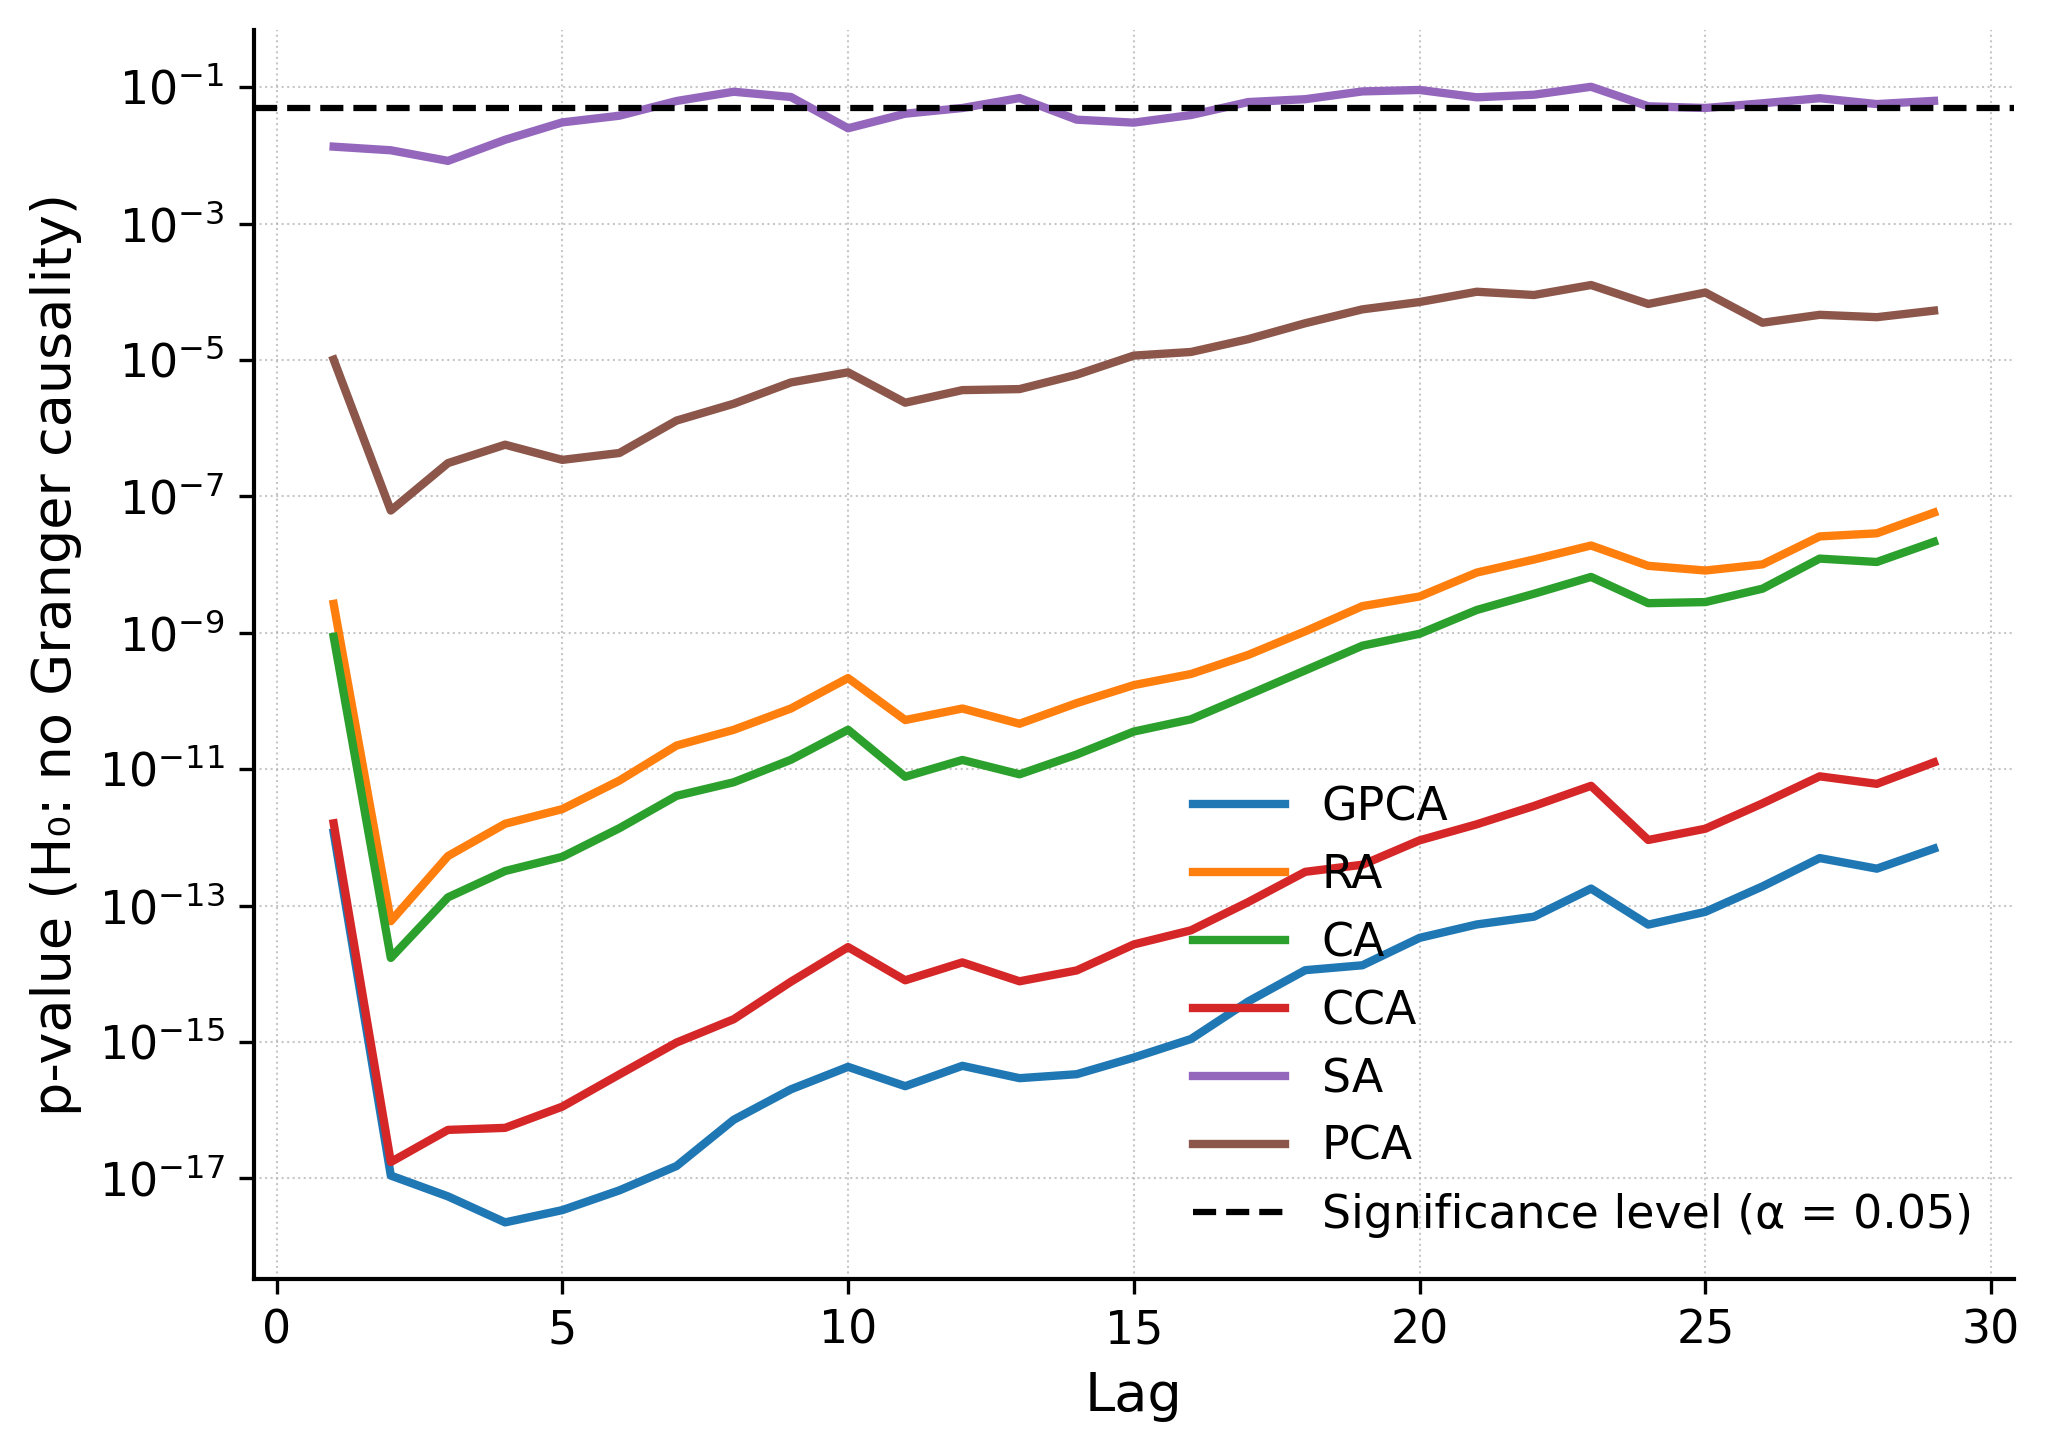

In [15]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- Global style adjustments ---
mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
})

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

# --- Plot lines ---
ax.plot(lags, results_gpca['p_value'], label='GPCA')
ax.plot(lags, results_ra['p_value'], label='RA')
ax.plot(lags, results_ca['p_value'], label='CA')
ax.plot(lags, results_cca['p_value'], label='CCA')
ax.plot(lags, results_sa['p_value'], label='SA')
ax.plot(lags, results_pc['p_value'], label='PCA')

# --- Rejection threshold ---
ax.axhline(
    y=0.05,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='Significance level (α = 0.05)'
)

# --- Axes formatting ---
ax.set_xlabel('Lag')
ax.set_ylabel('p-value (H₀: no Granger causality)')
ax.set_yscale('log')

# Optional: improve log tick formatting
ax.yaxis.set_major_formatter(mpl.ticker.LogFormatterMathtext())

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Subtle grid
ax.grid(True, which='both', linestyle=':', linewidth=0.5, alpha=0.7)

# Legend outside if many lines
ax.legend(frameon=False, loc='best')

plt.tight_layout()

# Save for publication (vector format preferred)
plt.savefig(f"../figures/granger_pvalues_{region}_coarsen-{coarsen_factor}_lag-{gpca.maxlag}.pdf", bbox_inches='tight')
plt.savefig(f"../figures/granger_pvalues_{region}_coarsen-{coarsen_factor}_lag-{gpca.maxlag}.png", dpi=600, bbox_inches='tight')

plt.show()

In [16]:
lag_min_gpca = lag#results_gpca['p_value'].argmin()+1
lag_min_ra = lag#results_ra['p_value'].argmin()+1
lag_min_ca = lag#results_ca['p_value'].argmin()+1
lag_min_cca = lag#results_cca['p_value'].argmin()+1
lag_min_sa = lag#results_sa['p_value'].argmin()+1
lag_min_pc = lag#results_pc['p_value'].argmin()+1

### Results

In [18]:
import pandas as pd

# ============================================================
# 1. Compute explained variance ratio (scalar per method)
# ============================================================
evr_gpca = explained_variance_ratio_fast(anomalies_test, w_gpca)
evr_cca  = explained_variance_ratio_fast(anomalies_test, w_cca)
evr_ca   = explained_variance_ratio_fast(anomalies_test, w_ca)
evr_ra   = explained_variance_ratio_fast(anomalies_test, w_ra)
evr_sa   = explained_variance_ratio_fast(anomalies_test, w_sa)
evr_pc   = explained_variance_ratio_fast(anomalies_test, w_pc)


# ============================================================
# 2. Attach EVR to each results DataFrame (scalar broadcast)
# ============================================================
results_gpca = results_gpca.assign(EVR=evr_gpca)
results_cca  = results_cca.assign(EVR=evr_cca)
results_ca   = results_ca.assign(EVR=evr_ca)
results_ra   = results_ra.assign(EVR=evr_ra)
results_sa   = results_sa.assign(EVR=evr_sa)
results_pc   = results_pc.assign(EVR=evr_pc)


# ============================================================
# 3. Combine results at the selected lag
# ============================================================
combined = pd.concat(
    [
        results_gpca[results_gpca['lag'] == lag_min_gpca],
        results_cca[results_cca['lag'] == lag_min_cca],
        results_ca[results_ca['lag'] == lag_min_ca],
        results_ra[results_ra['lag'] == lag_min_ra],
        results_sa[results_sa['lag'] == lag_min_sa],
        results_pc[results_pc['lag'] == lag_min_pc],
    ],
    keys=['GPCA', 'CCA', 'Composites', 'Regression', 'Spatial Average', 'PCA']
).reset_index(level=0).rename(columns={'level_0': 'Method'})

# ============================================================
# 4. Export to LaTeX (include EVR)
# ============================================================
latex_table = combined[['EVR', 'F_statistic', 'p_value']].to_latex(
    index=True,
    caption=f"Comparison of Results by Method at lag = {gpca.maxlag}",
    label="tab:results_by_method",
    float_format="%.6f",
    escape=True
)

# ============================================================
# 5. Save LaTeX table to file
# ============================================================
output_path = (
    f"../tables/teleconnection_pvalues_precipitation_"
    f"{region}_coarsen-{coarsen_factor}_lag-{gpca.maxlag}.tex"
)

with open(output_path, "w") as f:
    f.write(latex_table)


In [19]:
combined

,Method,lag,Y_column,F_statistic,df1,df2,p_value,F_critical,alpha_used,interpretation,EVR
2,GPCA,3,1,28.186462,3,3279,5.445839e-18,2.607618,0.05,Reject H₀ (α=0.05000): X Granger-causes Y (lag=3),0.034751
2,CCA,3,1,26.633346,3,3279,5.144701e-17,2.607618,0.05,Reject H₀ (α=0.05000): X Granger-causes Y (lag=3),0.036018
2,Composites,3,1,21.211087,3,3279,1.321156e-13,2.607618,0.05,Reject H₀ (α=0.05000): X Granger-causes Y (lag=3),0.038630
2,Regression,3,1,20.249375,3,3279,5.323694e-13,2.607618,0.05,Reject H₀ (α=0.05000): X Granger-causes Y (lag=3),0.038630
2,Spatial Average,3,1,3.922191,3,3279,8.300885e-03,2.607618,0.05,Reject H₀ (α=0.05000): X Granger-causes Y (lag=3),0.016662
2,PCA,3,1,11.086219,3,3279,3.073706e-07,2.607618,0.05,Reject H₀ (α=0.05000): X Granger-causes Y (lag=3),0.044783


In [20]:
# Normalising and reshaping weights to maps
weights_gpca = np2D_to_np3D(w_gpca[None, :], mask)[0, :, :]
weights_ra = np2D_to_np3D(w_ra[None, :], mask)[0, :, :]
weights_ca = np2D_to_np3D( w_ca[None, :], mask)[0, :, :]
weights_cca = np2D_to_np3D(w_cca[None, :], mask)[0, :, :]
weights_sa = np2D_to_np3D(w_sa[None, :], mask)[0, :, :]
weights_pc = -np2D_to_np3D(w_pc[None, :], mask)[0, :, :]

# Normalising and reshaping weights to maps
signi_gpca = np2D_to_np3D(significance_gpca[None, :], mask)[0, :, :]
signi_ra = np2D_to_np3D(significance_ra[None, :], mask)[0, :, :]
signi_ca = np2D_to_np3D( significance_ca[None, :], mask)[0, :, :]
signi_cca = np2D_to_np3D(significance_cca[None, :], mask)[0, :, :]
signi_sa = np2D_to_np3D(significance_sa[None, :], mask)[0, :, :]
signi_pc = np2D_to_np3D(significance_pc[None, :], mask)[0, :, :]
    
weights = {'GPCA':{'weights':weights_gpca, 'significances':signi_gpca, 'p-value':results_gpca[results_gpca['lag']==lag_min_gpca]['p_value']}, 
            'Regression':{'weights':weights_ra, 'significances':signi_ra, 'p-value':results_ra[results_ra['lag']==lag_min_ra]['p_value']},
            'Composites':{'weights':weights_ca, 'significances':signi_ca, 'p-value':results_ca[results_ca['lag']==lag_min_ca]['p_value']},
            'CCA':{'weights':weights_cca, 'significances':signi_cca, 'p-value':results_cca[results_cca['lag']==lag_min_cca]['p_value']},
            'Average':{'weights':weights_sa, 'significances':signi_sa, 'p-value':results_sa[results_sa['lag']==lag_min_sa]['p_value']},
            'PCA':{'weights':weights_pc, 'significances':signi_pc, 'p-value':results_pc[results_pc['lag']==lag_min_pc]['p_value']}
        }

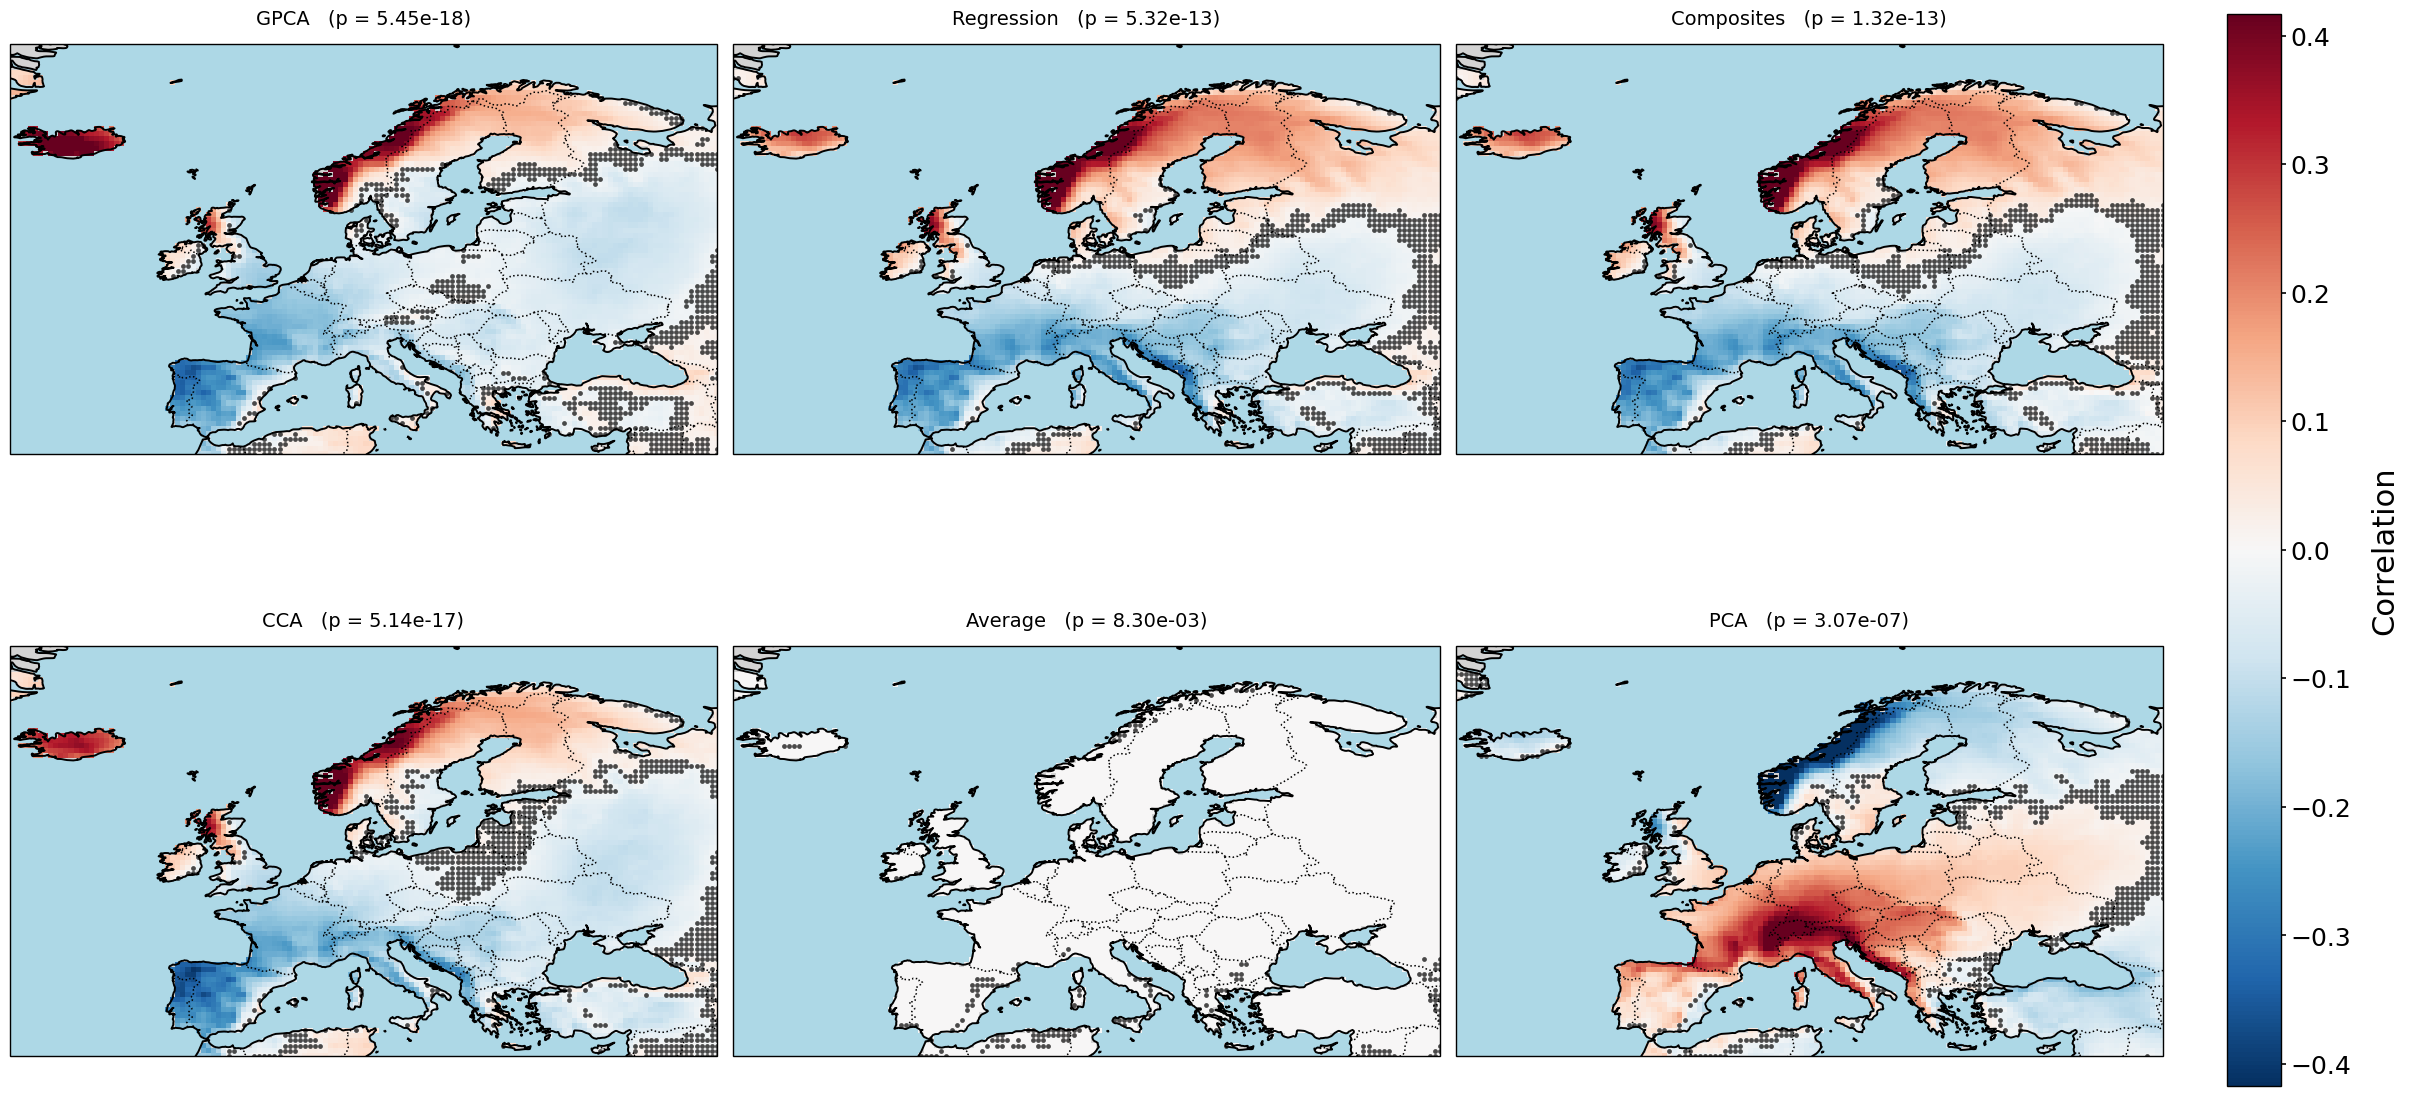

In [21]:
path = f'../figures/teleconnection_weights_precipitation_{region}_coarsen-{coarsen_factor}_lag-{gpca.maxlag}.png'

lon=precip_anomalies['tp'].longitude.values
lat=precip_anomalies['tp'].latitude.values
plot_weight_maps(weights, 'Precipitation', lon, lat, extent=None, save_path=path)